# Sales Analytics Dashboard — Data Analysis Notebook

This notebook walks through the full Python + SQL portion of the
**Sales Analytics Dashboard** project:

1. Load the raw (messy) sales data
2. Clean it with pandas
3. Load the cleaned data into SQLite
4. Run the analytical SQL queries (monthly sales, top products,
   best customers, revenue by category, revenue by country)
5. Visualize the results with matplotlib (these charts double as a
   preview of what the Power BI dashboard will show)

> Beginner note: every step is commented so you can follow *why*
> each line exists, not just *what* it does.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

# Display settings for readability
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (9, 5)


## 2. Load the raw dataset
The raw CSV was generated by `data/generate_data.py` and intentionally contains some messy data (duplicates, missing values, inconsistent text) to practice cleaning on.

In [2]:
raw_df = pd.read_csv("../data/sales_data_raw.csv")
print("Raw shape:", raw_df.shape)
raw_df.head()


Raw shape: (10100, 12)


,OrderID,Date,Customer,Product,Category,Quantity,UnitPrice,Discount,Revenue,City,Country,Salesperson
0,109946,2024-07-25,franklin wright,CAMPING TENT,Sports & Outdoors,2,266.06,0.2,425.70,los angeles,United States,Elena Petrova
1,104960,2023-12-18,Jordan Williams,wireless mouse,Electronics,3,27.24,0.0,81.72,Manchester,united kingdom,Farah Haddad
2,105898,2024-04-10,James Ferrell,Desk Lamp,Furniture,6,38.24,0.0,229.44,Houston,United States,Farah Haddad
3,109361,2023-01-14,Jeffrey Howell,Desk Lamp,Furniture,9,44.51,0.1,360.53,New York,united states,Alice Carter
4,107454,2023-01-08,Lori Simmons,Notebook Set,Office Supplies,8,8.21,0.0,65.68,Dubai,United Arab Emirates,ALICE CARTER


In [3]:
# Quick data-quality check before cleaning
print("Missing values per column:")
print(raw_df.isna().sum())
print("\nDuplicate rows:", raw_df.duplicated().sum())


Missing values per column:
OrderID          0
Date             0
Customer       202
Product          0
Category         0
Quantity         0
UnitPrice        0
Discount       202
Revenue          0
City           202
Country          0
Salesperson      0
dtype: int64

Duplicate rows: 14


## 3. Clean the data with pandas

Cleaning steps:
- Remove exact duplicates and duplicate `OrderID`s
- Trim whitespace and standardize text casing
- Fill/handle missing values
- Fix invalid quantities (negative values)
- Convert data types (dates, numeric columns)
- Recalculate `Revenue` so it's always consistent with Quantity, UnitPrice, and Discount

(This logic lives in `notebooks/clean_data.py` as a standalone script too, so it can be scheduled/run outside the notebook.)


In [4]:
df = raw_df.copy()

# Remove duplicates
df = df.drop_duplicates()
df = df.drop_duplicates(subset="OrderID", keep="first")

# Standardize text columns
text_cols = ["Customer", "Product", "Category", "City", "Country", "Salesperson"]
for col in text_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.title()
        .replace({"Nan": np.nan})
    )

# Handle missing values
df["Customer"] = df["Customer"].fillna("Unknown Customer")
df = df.dropna(subset=["City", "Country"])
df["Discount"] = df["Discount"].fillna(0)

# Fix invalid quantities
df["Quantity"] = df["Quantity"].abs()
df = df[df["Quantity"] > 0]
df["Discount"] = df["Discount"].clip(lower=0, upper=0.5)

# Convert data types
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])
df["OrderID"] = df["OrderID"].astype(int)
df["Quantity"] = df["Quantity"].astype(int)
df["UnitPrice"] = df["UnitPrice"].astype(float).round(2)
df["Discount"] = df["Discount"].astype(float).round(2)

# Recalculate revenue for consistency
df["Revenue"] = (df["Quantity"] * df["UnitPrice"] * (1 - df["Discount"])).round(2)

# Helper date columns for reporting
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["MonthName"] = df["Date"].dt.strftime("%B")
df["YearMonth"] = df["Date"].dt.strftime("%Y-%m")

df = df.sort_values("Date").reset_index(drop=True)

print("Cleaned shape:", df.shape)
df.head()


Cleaned shape: (9798, 16)


,OrderID,Date,Customer,Product,Category,Quantity,UnitPrice,Discount,Revenue,City,Country,Salesperson,Year,Month,MonthName,YearMonth
0,109062,2023-01-01,William Miller,Ballpoint Pens (Box),Office Supplies,7,4.66,0.05,30.99,Osaka,Japan,Ivan Petrov,2023,1,January,2023-01
1,101897,2023-01-01,Dana Martinez,4K Monitor,Electronics,10,256.73,0.00,2567.30,London,United Kingdom,Alice Carter,2023,1,January,2023-01
2,101139,2023-01-01,John Whitehead,Printer Paper (Ream),Office Supplies,3,11.73,0.05,33.43,Osaka,Japan,Ivan Petrov,2023,1,January,2023-01
3,101571,2023-01-01,Tyler Harris,Air Fryer,Home & Kitchen,10,75.32,0.20,602.56,Sydney,Australia,Julia Romano,2023,1,January,2023-01
4,104524,2023-01-01,Jennifer Hernandez,Running Shoes,Apparel,1,74.26,0.10,66.83,Delhi,India,Hana Suzuki,2023,1,January,2023-01


In [5]:
# Save the cleaned dataset (also produced by notebooks/clean_data.py)
df.to_csv("../data/sales_data_clean.csv", index=False)
print("Saved cleaned data to ../data/sales_data_clean.csv")


Saved cleaned data to ../data/sales_data_clean.csv


## 4. Load cleaned data into SQLite
This creates `data/sales.db`, which Power BI can connect to directly using an ODBC/SQLite connector, or which can be queried with any SQL client.

In [6]:
conn = sqlite3.connect("../data/sales.db")
df.to_sql("sales", conn, if_exists="replace", index=False)

# Helpful indexes for faster querying
cur = conn.cursor()
cur.execute("CREATE INDEX IF NOT EXISTS idx_date ON sales(Date)")
cur.execute("CREATE INDEX IF NOT EXISTS idx_product ON sales(Product)")
cur.execute("CREATE INDEX IF NOT EXISTS idx_customer ON sales(Customer)")
cur.execute("CREATE INDEX IF NOT EXISTS idx_country ON sales(Country)")
conn.commit()

print("Rows in SQLite table:", cur.execute("SELECT COUNT(*) FROM sales").fetchone()[0])


Rows in SQLite table: 9798


## 5. SQL Analysis Queries
Each query below matches a `.sql` file in the `/sql` folder, so they can be reused outside Python (e.g., directly in Power BI's query editor or any SQL client).

### 5.1 Monthly Sales

In [7]:
monthly_sales = pd.read_sql_query('''
    SELECT
        YearMonth,
        COUNT(DISTINCT OrderID) AS TotalOrders,
        SUM(Quantity)           AS TotalUnitsSold,
        ROUND(SUM(Revenue), 2)  AS TotalRevenue,
        ROUND(AVG(Revenue), 2)  AS AvgOrderRevenue
    FROM sales
    GROUP BY YearMonth
    ORDER BY YearMonth;
''', conn)
monthly_sales


,YearMonth,TotalOrders,TotalUnitsSold,TotalRevenue,AvgOrderRevenue
0,2023-01,374,1965,165237.02,441.81
1,2023-02,323,1777,146900.33,454.80
2,2023-03,354,1992,158948.24,449.01
3,2023-04,329,1821,139935.38,425.34
4,2023-05,354,1970,151439.77,427.80
5,2023-06,337,1845,144342.71,428.32
6,2023-07,387,1973,160809.09,415.53
7,2023-08,369,2045,168926.87,457.80
8,2023-09,329,1733,151709.74,461.12
9,2023-10,315,1712,139389.88,442.51


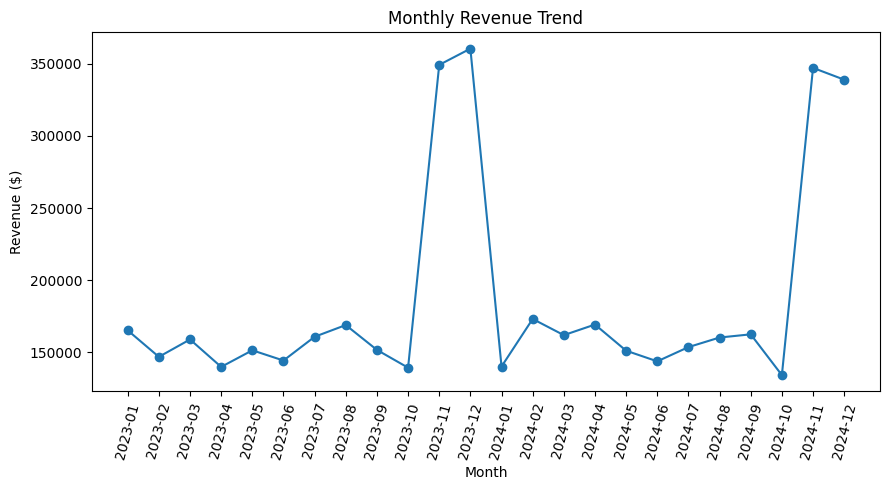

In [8]:
plt.plot(monthly_sales["YearMonth"], monthly_sales["TotalRevenue"], marker="o")
plt.xticks(rotation=75)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.savefig("../screenshots/monthly_sales_trend.png", dpi=120)
plt.show()


### 5.2 Top 10 Products

In [9]:
top_products = pd.read_sql_query('''
    SELECT
        Product,
        Category,
        COUNT(DISTINCT OrderID) AS TotalOrders,
        SUM(Quantity)           AS TotalUnitsSold,
        ROUND(SUM(Revenue), 2)  AS TotalRevenue
    FROM sales
    GROUP BY Product, Category
    ORDER BY TotalRevenue DESC
    LIMIT 10;
''', conn)
top_products


,Product,Category,TotalOrders,TotalUnitsSold,TotalRevenue
0,Standing Desk,Furniture,447,2451,738695.50
1,4K Monitor,Electronics,447,2388,619333.92
2,Camping Tent,Sports & Outdoors,415,2310,422570.51
3,Office Chair,Furniture,412,2181,395911.61
4,Cookware Set,Home & Kitchen,473,2606,383340.62
5,Winter Jacket,Apparel,443,2447,320548.44
6,Air Fryer,Home & Kitchen,444,2358,249168.91
7,Running Shoes,Apparel,434,2410,195038.76
8,Mechanical Keyboard,Electronics,458,2503,188067.80
9,Coffee Maker,Home & Kitchen,430,2253,186812.01


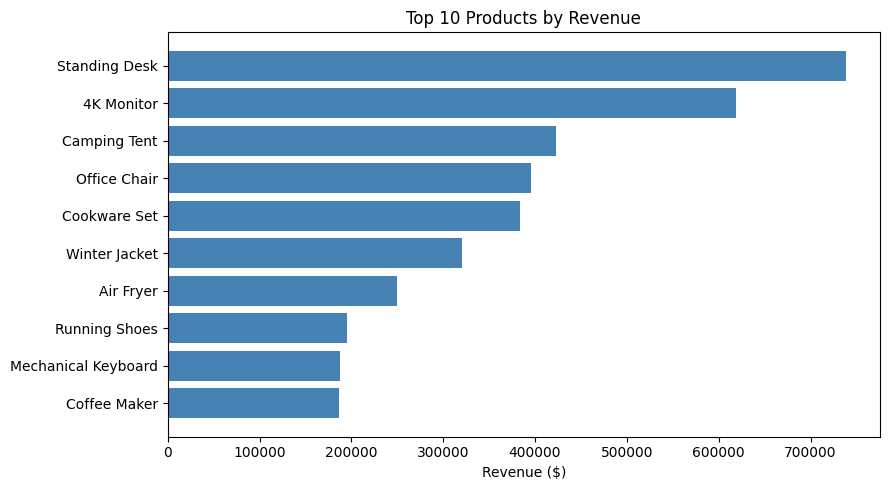

In [10]:
plt.barh(top_products["Product"][::-1], top_products["TotalRevenue"][::-1], color="steelblue")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue ($)")
plt.tight_layout()
plt.savefig("../screenshots/top_10_products.png", dpi=120)
plt.show()


### 5.3 Best Customers

In [11]:
best_customers = pd.read_sql_query('''
    SELECT
        Customer,
        COUNT(DISTINCT OrderID)  AS TotalOrders,
        SUM(Quantity)            AS TotalUnitsPurchased,
        ROUND(SUM(Revenue), 2)   AS TotalRevenue,
        ROUND(AVG(Revenue), 2)   AS AvgOrderValue
    FROM sales
    WHERE Customer <> 'Unknown Customer'
    GROUP BY Customer
    ORDER BY TotalRevenue DESC
    LIMIT 20;
''', conn)
best_customers.head(10)


,Customer,TotalOrders,TotalUnitsPurchased,TotalRevenue,AvgOrderValue
0,Kim Morrow,12,90,13248.11,1104.01
1,Steve Rivera,11,76,12086.75,1098.80
2,Paul Lewis,11,67,12072.15,1097.47
3,Stephanie Salazar,9,58,11516.59,1279.62
4,Jeremy Reed,7,51,11171.41,1595.92
5,Robert Harrison,8,38,11008.59,1376.07
6,Jennifer Adkins,15,85,10898.08,726.54
7,Raymond Chapman,16,108,10885.49,680.34
8,Wayne Morgan,14,75,10761.12,768.65
9,Kevin Oconnor,12,78,10471.88,872.66


### 5.4 Revenue by Category

In [12]:
revenue_by_category = pd.read_sql_query('''
    SELECT
        Category,
        COUNT(DISTINCT OrderID) AS TotalOrders,
        SUM(Quantity)           AS TotalUnitsSold,
        ROUND(SUM(Revenue), 2)  AS TotalRevenue,
        ROUND(100.0 * SUM(Revenue) / (SELECT SUM(Revenue) FROM sales), 2) AS PctOfTotalRevenue
    FROM sales
    GROUP BY Category
    ORDER BY TotalRevenue DESC;
''', conn)
revenue_by_category


,Category,TotalOrders,TotalUnitsSold,TotalRevenue,PctOfTotalRevenue
0,Furniture,1303,7085,1226630.31,27.42
1,Electronics,2273,12619,1061065.54,23.72
2,Home & Kitchen,1803,9742,966977.49,21.62
3,Apparel,1349,7417,568889.99,12.72
4,Sports & Outdoors,1299,7153,532141.43,11.90
5,Office Supplies,1771,9832,117574.49,2.63


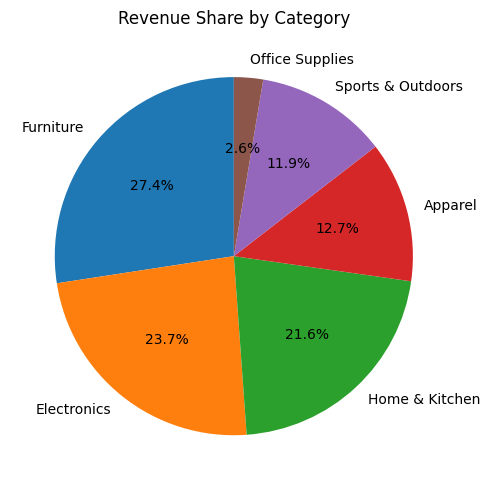

In [13]:
plt.pie(
    revenue_by_category["TotalRevenue"],
    labels=revenue_by_category["Category"],
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("Revenue Share by Category")
plt.tight_layout()
plt.savefig("../screenshots/revenue_by_category.png", dpi=120)
plt.show()


### 5.5 Revenue by Country

In [14]:
revenue_by_country = pd.read_sql_query('''
    SELECT
        Country,
        COUNT(DISTINCT OrderID) AS TotalOrders,
        SUM(Quantity)           AS TotalUnitsSold,
        ROUND(SUM(Revenue), 2)  AS TotalRevenue,
        ROUND(AVG(Revenue), 2)  AS AvgOrderValue
    FROM sales
    GROUP BY Country
    ORDER BY TotalRevenue DESC;
''', conn)
revenue_by_country


,Country,TotalOrders,TotalUnitsSold,TotalRevenue,AvgOrderValue
0,United States,1705,9393,808959.85,474.46
1,Canada,874,4750,414481.80,474.24
2,Japan,849,4742,412922.31,486.36
3,Germany,907,4960,409510.95,451.50
4,France,832,4592,403993.87,485.57
5,United Kingdom,870,4880,394913.74,453.92
6,India,849,4546,364642.65,429.50
7,Australia,838,4584,359978.75,429.57
8,Brazil,842,4711,354415.96,420.92
9,Spain,797,4322,346690.96,434.99


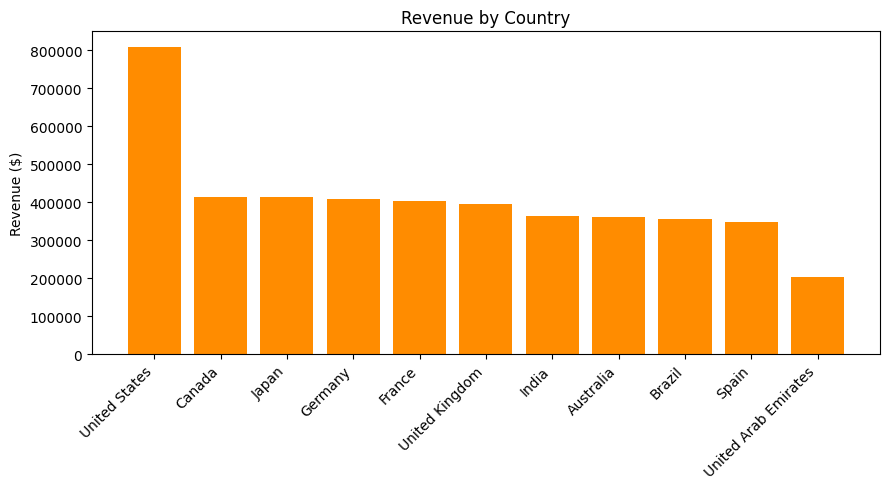

In [15]:
plt.bar(revenue_by_country["Country"], revenue_by_country["TotalRevenue"], color="darkorange")
plt.xticks(rotation=45, ha="right")
plt.title("Revenue by Country")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.savefig("../screenshots/revenue_by_country.png", dpi=120)
plt.show()


## 6. Close the connection

In [16]:
conn.close()
print("Done. Cleaned data, SQLite DB, and chart screenshots are ready for Power BI.")


Done. Cleaned data, SQLite DB, and chart screenshots are ready for Power BI.


## 7. Next Step: Power BI

Connect Power BI to `data/sales.db` (SQLite ODBC driver) or import
`data/sales_data_clean.csv` directly, then follow the build guide in
`dashboard/dashboard_recommendations.md` to construct the KPI cards,
charts, map, and slicers.
